# TabPFN parameters

With a gradient-boosting model you spend real effort searching hyperparameters: tree depth, learning rate,
number of trees, number of leaves, minimum number of instances in leaf, subsample, column sample, regularization. With TabPFN that search is gone. The
model is **pretrained**, its weights are fixed, and there is no train-time fit to tune. What is left
is a short list of **inference settings**, and the defaults are strong.

This notebook tours them, measures the few that actually move the needle, and shows how to inspect
what TabPFN inferred about your data. 

Where the actual "search" really happens is in the context creation, but this is not covered here.

## What's in here

A map of the notebook, in reading order:

1. **Parameter map**: every inference setting at a glance, with its default and when to touch it.
2. **How the preprocessing builds its views**: the one mechanism behind TabPFN's "ensemble", the same
   network reading several differently preprocessed copies of your data, plus the transform menu and how
   to drive it yourself.
3. **What the knobs do to the output**: the measured half. How many views you need (`n_estimators`), what
   keeps them diverse, which knobs move the ranking versus the calibration, and how shrinking the context
   behaves.
4. **Calibration knobs**: `balance_probabilities` and `softmax_temperature`, the two that move a
   fixed-threshold decision without touching the ranking.
5. **Speed and memory**: `fit_mode` and the caching knobs, the same predictions at different time and
   memory cost.
6. **Inferred settings**: reading back what TabPFN decided about your data, and the checkpoint limits.
7. **Other knobs**, then the **Takeaways**.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from tabpfn import TabPFNClassifier

def make_data(n=6000, n_features=12, noise=1.5, positive_rate=None, seed=0):
    """A synthetic binary task with a nonlinear signal plus noise."""
    rng = np.random.RandomState(seed)
    X = rng.randn(n, n_features)
    signal = X[:, 0] * X[:, 1] + X[:, 2] ** 2 - X[:, 3] * X[:, 4] + 0.8 * X[:, 5]
    logit = signal + noise * rng.randn(n)
    if positive_rate is None:
        label = (logit > np.median(logit)).astype(int)               # balanced
    else:
        label = (logit > np.quantile(logit, 1 - positive_rate)).astype(int)
    table = pd.DataFrame(X, columns=[f"x{i}" for i in range(n_features)])
    return table, label

def load_openml_binary(name, n_cap=2500, seed=0):
    """Load a binary OpenML dataset as numeric features and 0/1 labels, subsampled for speed."""
    data = fetch_openml(name=name, version=1, as_frame=True)
    X = data.frame.drop(columns=[data.target.name]).select_dtypes(include=[np.number]).astype(float)
    y = pd.factorize(data.target)[0]
    if len(X) > n_cap:
        index = np.random.RandomState(seed).permutation(len(X))[:n_cap]
        X, y = X.iloc[index].reset_index(drop=True), y[index]
    return X, y

def expected_calibration_error(y_true, probabilities, bins=15):
    """Average gap between predicted confidence and actual outcome frequency.

    Predictions are sorted into equal-width probability bins. Within each bin we
    compare the average predicted probability against the actual fraction of
    positives, then average those gaps, weighting each bin by how many predictions
    fall in it. Lower is better calibrated.
    """
    bin_edges = np.linspace(0, 1, bins + 1)
    bin_numbers = np.clip(np.digitize(probabilities, bin_edges) - 1, 0, bins - 1)
    calibration_gap = 0.0
    for b in range(bins):
        in_bin = bin_numbers == b
        if in_bin.any():
            average_prediction = probabilities[in_bin].mean()
            actual_frequency = y_true[in_bin].mean()
            calibration_gap += in_bin.mean() * abs(actual_frequency - average_prediction)
    return calibration_gap

## Parameter map

Every TabPFN inference setting, with its default and when you would reach for it:

| Parameter (default) | What it controls | When to touch it |
|---|---|---|
| `n_estimators` (8) | the requested number of differently-preprocessed copies of the data to ensemble (each estimator has its own preprocessing pipeline). The resolved count is `n_estimators_`, which can exceed the request on wide data | lower for speed, higher for a small accuracy bump |
| `auto_scale_n_estimators` (True) | on wide data, raise `n_estimators` so every feature is covered by at least one estimator, capped at 32 | leave on; set False to pin exactly the count you requested |
| `softmax_temperature` (0.9) | sharpen or soften the predicted probabilities | calibration, fixed-threshold decisions |
| `balance_probabilities` (False) | reweight outputs toward balanced classes | imbalanced data, to move the operating point |
| `average_before_softmax` (False) | average estimator logits before the softmax, not after | many classes or calibration, with `n_estimators > 1` |
| `categorical_features_indices` (None) | which columns are treated as categorical | when auto-detection mis-types a column |
| `ignore_pretraining_limits` (False) | allow data beyond the recommended size | many rows or features (expect some degradation) |
| `inference_config` (None) | override the internal preprocessing. This is where all of the preprocessing choices can be made  | advanced: scaling, outlier clip, categorical thresholds |
| `model_path` ('auto') | which checkpoint to load | 'auto' loads the v3 default; rarely changed |
| `fit_mode` ('fit_preprocessors') | how much of the context is cached at fit time | speed against memory for repeated prediction |
| `keep_cache_on_device` (True) | only with `fit_mode="fit_with_cache"`: keep each estimator's KV cache on the inference device for speed, or offload it to CPU when False | False to fit a large cached context in limited device memory |
| `memory_saving_mode` ('auto') | batch internal computations to save memory | tight GPU, or hand-tuning speed |
| `inference_precision` ('auto') | numeric precision of the forward pass | reproducibility (pin a dtype) against speed |
| `device` ('auto') | CPU or GPU | force a specific device |
| `n_preprocessing_jobs` (1) | CPU workers for preprocessing | many cores and `n_estimators > 1` |
| `eval_metric` / `tuning_config` (None) | post-hoc calibration and threshold tuning for a metric | when you optimize a specific metric |
| `differentiable_input` (False) | make the preprocessing differentiable | explainability, prompt-tuning |
| `random_state` (0) | reproducibility | already fixed to 0 by default |
| `show_progress_bar` (False) | progress bar during inference | long runs |

The defaults are strong almost everywhere. The next cells measure the ones that actually move
accuracy or the clock, then show how to read and override the rest.

## How the preprocessing builds its views

The most important section, and the one with the most moving parts, so it comes in two halves. This first
half is the mechanism: what the preprocessing actually is, every knob it exposes, and how to set them
yourself, with no comparison of outputs yet. The second half, [what the knobs do to the output](#what-the-knobs-do-to-the-output), measures the consequences.

TabPFN's "ensemble" is not several models. It is the same frozen network reading several differently
preprocessed views of your data, with the predictions averaged. Two parameters control it:

- `n_estimators` = the **requested** number of views to average. The fitted model reports the resolved
  count as `n_estimators_`, which exceeds the request only when `auto_scale_n_estimators` raises it on
  wide data (every dataset here is narrow, so the two match).
- `inference_config` = **what each view is** (the scaling recipe, the categorical handling, and what
  makes one view differ from the next).

### Each estimator sees a different view

After `.fit()`, each estimator is a `TabPFNEnsembleMember` in `clf.executor_.ensemble_members` with its
own recipe and fitted pipeline. The cell below reads them off a default 8-estimator model.

In [2]:
# Inspect the ensemble TabPFN actually built. After .fit(), each estimator is a TabPFNEnsembleMember on
# clf.executor_.ensemble_members, carrying its config and its fitted preprocessing pipeline. We print the
# recipe, the per-estimator column shift, the class permutation, and the fitted step names.
X, y = make_data(n=4000, seed=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)

inspect_model = TabPFNClassifier(n_estimators=8, random_state=0).fit(X_train, y_train)
print(f"requested n_estimators={inspect_model.n_estimators}, resolved n_estimators_={inspect_model.n_estimators_}\n")
for index, member in enumerate(inspect_model.executor_.ensemble_members):
    config = member.config
    recipe = config.preprocess_config
    print(f"est{index}: {recipe.name:24s} cat={recipe.categorical_name:38s} "
          f"shift={config.feature_shift_count} class_perm={config.class_permutation.tolist()}")
fitted_steps = [type(step).__name__ for step, _ in inspect_model.executor_.ensemble_members[0].cpu_preprocessor.steps]
print("\nfitted steps (the same three for every estimator):", fitted_steps)

requested n_estimators=8, resolved n_estimators_=8

est0: squashing_scaler_default cat=ordinal_very_common_categories_shuffled shift=850 class_perm=[0, 1]
est1: squashing_scaler_default cat=ordinal_very_common_categories_shuffled shift=856 class_perm=[0, 1]
est2: squashing_scaler_default cat=ordinal_very_common_categories_shuffled shift=857 class_perm=[0, 1]
est3: squashing_scaler_default cat=ordinal_very_common_categories_shuffled shift=852 class_perm=[0, 1]
est4: quantile_uni             cat=numeric                                shift=854 class_perm=[1, 0]
est5: quantile_uni             cat=numeric                                shift=853 class_perm=[1, 0]
est6: quantile_uni             cat=numeric                                shift=855 class_perm=[1, 0]
est7: quantile_uni             cat=numeric                                shift=851 class_perm=[1, 0]

fitted steps (the same three for every estimator): ['RemoveConstantFeaturesStep', 'ReshapeFeatureDistributionsStep', 'EncodeCat

8 estimators, default menu = 2 recipes, split 4 / 4:

| estimators | numeric transform | categoricals | class order |
|---|---|---|---|
| 0-3 | squashing scaler, then append SVD | ordinal codes, shuffled | `[0, 1]` |
| 4-7 | quantile transform to uniform | codes as numbers | `[1, 0]` |

The transforms:

- **squashing scaler**: robust-center, then soft-clip. $z=\dfrac{x-q_{50}}{q_{75}-q_{25}}$, $x_{\text{out}}=\dfrac{z}{\sqrt{1+(z/B)^2}}$, $B=3$. Outliers saturate smoothly into $[-3,3]$; $\pm\infty\to\pm B$, NaN kept.
- **SVD** (`svd_quarter_components`): append the top $k=\max\!\left(1,\ \min(\lfloor n/10\rfloor+1,\ \lfloor p/4\rfloor)\right)$ components of $X=U\Sigma V^{\top}$ as extra columns; the originals stay.
- **quantile $\to$ uniform**: map each feature through its empirical CDF $\hat F$ to $[0,1]$ (a rank transform).
- **categoricals** (turning a category column into numbers): `numeric` keeps the existing integer codes as-is. `ordinal_very_common_categories_shuffled` ordinal-encodes (category $\to$ integer) only the columns whose categories are common (rarest category appears $\geq 10$ times) and low-cardinality (fewer than $n/10$ distinct values), then **randomizes the codes per estimator** so their order carries no ranking; other columns pass through. Other settings: `ordinal` (sorted codes), `ordinal_shuffled`, `onehot`, `none`.

Then every estimator runs the same 3 fitted steps: drop-constant-columns $\to$ reshape-distributions $\to$ encode-categoricals.

Every dataset in this notebook is numeric, so the categorical setting has no columns to act on here; the recipe name still prints in the config above.

The eight are not copies. How much do their predictions differ, and does sharing a recipe matter? The next cell reads each estimator's probabilities separately.

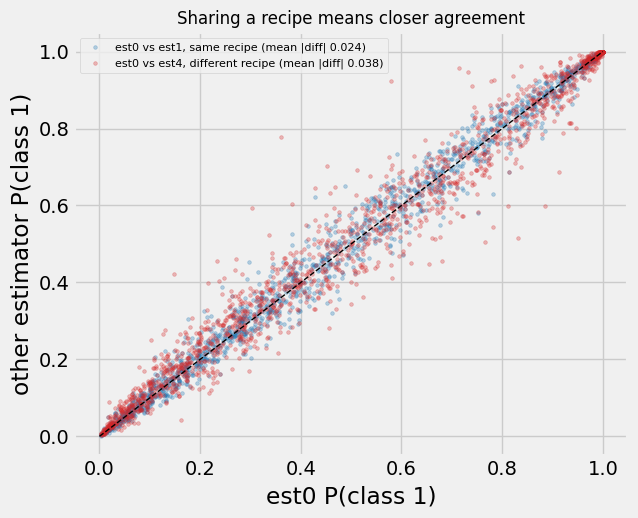

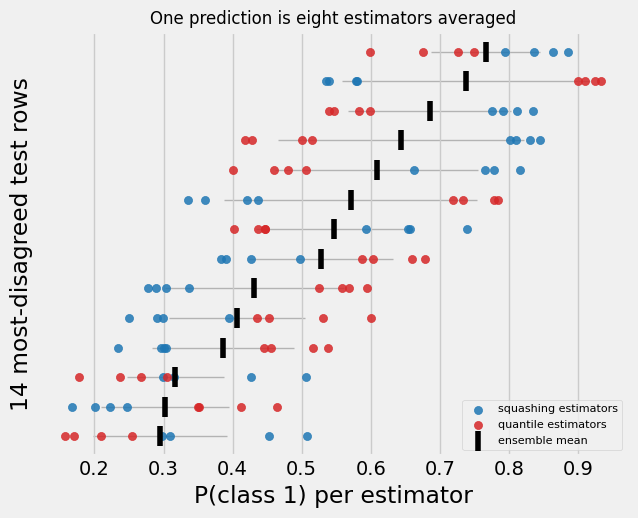

In [3]:
# How much do the per-estimator predictions actually differ, and does sharing a recipe matter? We read
# every estimator's P(class 1) off the same fitted model and look two ways, as two separate figures: a
# scatter of a same-recipe pair against a different-recipe pair, and, for the rows the estimators disagree
# on most, the eight predictions behind each averaged one.
import torch

def per_estimator_positive_proba(model, X):
    """P(class 1) from each estimator separately, shape (n_estimators, n_samples)."""
    logits = model.predict_raw_logits(X)  # (n_estimators, n_samples, n_classes), public API -> ndarray
    return torch.softmax(torch.from_numpy(logits) / model.softmax_temperature, dim=-1)[:, :, 1].numpy()

proba = per_estimator_positive_proba(inspect_model, X_test)
recipe_names = [member.config.preprocess_config.name for member in inspect_model.executor_.ensemble_members]
is_quantile = np.array(["quantile" in name for name in recipe_names])

# Figure 1: same-recipe pair against different-recipe pair.
same_diff = np.abs(proba[0] - proba[1]).mean()
cross_diff = np.abs(proba[0] - proba[4]).mean()
fig, ax = plt.subplots(figsize=(6.6, 5.4))
ax.scatter(proba[0], proba[1], s=7, alpha=0.30, color="#1f77b4",
           label=f"est0 vs est1, same recipe (mean |diff| {same_diff:.3f})")
ax.scatter(proba[0], proba[4], s=7, alpha=0.30, color="#d62728",
           label=f"est0 vs est4, different recipe (mean |diff| {cross_diff:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("est0 P(class 1)"); ax.set_ylabel("other estimator P(class 1)")
ax.set_title("Sharing a recipe means closer agreement", fontsize=12)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

# Figure 2: the 14 rows the estimators disagree on most, the eight predictions behind each average.
spread = proba.max(0) - proba.min(0)
most_disagreed = np.argsort(spread)[::-1][:14]
most_disagreed = most_disagreed[np.argsort(proba[:, most_disagreed].mean(0))]
fig, ax = plt.subplots(figsize=(6.6, 5.4))
for slot, row in enumerate(most_disagreed):
    ax.plot([proba[~is_quantile, row].mean(), proba[is_quantile, row].mean()], [slot, slot],
            color="0.7", lw=1, zorder=0)
    ax.scatter(proba[~is_quantile, row], [slot] * int((~is_quantile).sum()), color="#1f77b4",
               s=34, alpha=0.85, label="squashing estimators" if slot == 0 else None)
    ax.scatter(proba[is_quantile, row], [slot] * int(is_quantile.sum()), color="#d62728",
               s=34, alpha=0.85, label="quantile estimators" if slot == 0 else None)
    ax.scatter([proba[:, row].mean()], [slot], color="k", marker="|", s=220, zorder=3,
               label="ensemble mean" if slot == 0 else None)
ax.set_yticks([]); ax.set_xlabel("P(class 1) per estimator"); ax.set_ylabel("14 most-disagreed test rows")
ax.set_title("One prediction is eight estimators averaged", fontsize=12)
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

Same labels, so the marginal output distributions are nearly identical (each estimator averages about 0.49, std about 0.32). The difference is per row:

- **first figure**: the same-recipe pair (blue) hugs the diagonal; the different-recipe pair (red) scatters wider. Swapping squashing for quantile moves a prediction more than reshuffling columns does.
- **second figure**: the 14 most-disagreed rows. Typical rows keep the 8 estimators within about 0.08; here they span 0.3 or more of probability. Black tick = the average TabPFN reports.

Averaging these views is the job of `n_estimators`. How many do you need?

### The preprocessing menu

The configuration changes on several axes at once, not just the scaling, and every axis lives in
`inference_config`. The richest one is the numeric transform (`PreprocessorConfig.name`), the scaling and
reshaping step. Its families: identity (`none`), logs (`log`, `1_plus_log`, `exp`), power transforms
(`power`, `safepower`, `power_box`, `safepower_box`), quantile-to-uniform (`quantile_uni`, plus `_coarse`,
`_fine`, `_extrapolate`), quantile-to-normal (`quantile_norm`, plus `_coarse`, `_fine`), robust scaling
with a soft clip (`squashing_scaler_default`, `squashing_scaler_max10`, `robust`), and kernel-density
variants (`kdi`, `kdi_uni`, `norm_and_kdi`). The two cells below show what a few of these do to one
skewed column, and how the categorical encoding turns a category into numbers; both are illustrative on a
single column, not a benchmark.

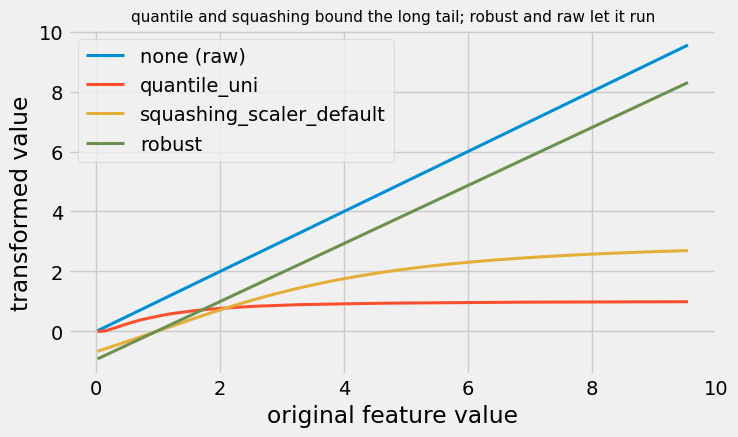

In [4]:
# What the scaling recipes do to a feature, as transfer curves: push a grid of raw values through the
# actual transforms TabPFN's recipes draw from, and plot transformed against original. Illustrative on one
# synthetic skewed column; the shape each transform produces is the point, not a benchmark.
from tabpfn.preprocessing.steps.adaptive_quantile_transformer import AdaptiveQuantileTransformer
from tabpfn.preprocessing.steps.squashing_scaler_transformer import SquashingScaler
from sklearn.preprocessing import RobustScaler

skewed = np.random.RandomState(0).lognormal(mean=0.0, sigma=1.0, size=4000).reshape(-1, 1)
grid = np.linspace(float(skewed.min()), float(np.percentile(skewed, 99)), 300).reshape(-1, 1)
transforms = {
    "none (raw)": None,
    "quantile_uni": AdaptiveQuantileTransformer(output_distribution="uniform"),
    "squashing_scaler_default": SquashingScaler(),
    "robust": RobustScaler(unit_variance=True),
}
fig, ax = plt.subplots(figsize=(7.6, 4.6))
for name, transform in transforms.items():
    if transform is None:
        mapped = grid.ravel()
    else:
        transform.fit(skewed)
        mapped = transform.transform(grid).ravel()
    ax.plot(grid.ravel(), mapped, lw=2.2, label=name)
ax.set_xlabel("original feature value"); ax.set_ylabel("transformed value")
ax.set_title("quantile and squashing bound the long tail; robust and raw let it run", fontsize=11)
ax.legend()
fig.tight_layout(); plt.show()

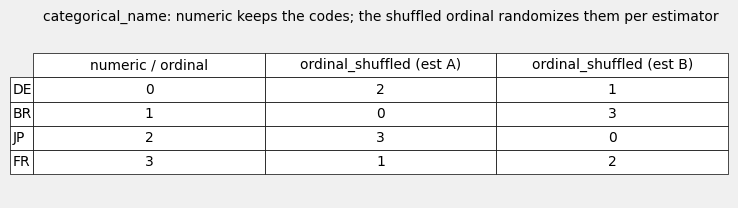

In [5]:
# What the recipe's categorical_name does to a category column. The default either keeps the existing
# integer codes (numeric) or ordinal-encodes and randomizes them per estimator (the shuffled variant);
# onehot would spend one 0/1 column per level. The real modality detection lives in the Categoricals chapter.
levels = ["DE", "BR", "JP", "FR"]
encodings = pd.DataFrame(
    {"numeric / ordinal": [0, 1, 2, 3],
     "ordinal_shuffled (est A)": [2, 0, 3, 1],
     "ordinal_shuffled (est B)": [1, 3, 0, 2]},
    index=levels,
)
fig, ax = plt.subplots(figsize=(7.6, 2.3))
ax.axis("off")
table = ax.table(cellText=encodings.values, rowLabels=encodings.index, colLabels=encodings.columns,
                 cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)
ax.set_title("categorical_name: numeric keeps the codes; the shuffled ordinal randomizes them per estimator",
             fontsize=10)
fig.tight_layout()
plt.show()

### The full menu, as a reference

Every setting, in two groups: what varies from one estimator to the next (the diversity sources), and
what every estimator shares. All live in `inference_config`.

| Setting (default) | What varies per estimator | When it fires |
|---|---|---|
| `PREPROCESS_TRANSFORMS` (2-recipe menu) | the scaling + categorical recipe | always; recipes repeat once `n_estimators` exceeds the menu length |
| `FEATURE_SHIFT_METHOD` (`"shuffle"`) | column order | always; the main v3 source. `"rotate"` rolls by `feature_shift_count`, `None` is off |
| `CLASS_SHIFT_METHOD` (`"shuffle"`) | which class is treated as first | always, but the weakest source in v3 (shown later) |
| `FEATURE_SUBSAMPLING_METHOD` (`"auto"`) | the column subset | only when features exceed `max_features_per_estimator` (200 in the v3 menu) |
| `SUBSAMPLE_SAMPLES` (`None`) | the row subset | off by default; set an int or float to turn it on |

When the feature count is larger than `max_features_per_estimator` (200), a single round of subsets may
not touch every column, so `auto_scale_n_estimators` raises the resolved `n_estimators_` until each
feature lands in at least one estimator, capped at 32. Past that cap some columns can go unsampled
unless you raise `n_estimators` yourself.

### Shared policies (the same for every estimator)

| Setting (default) | Effect |
|---|---|
| `OUTLIER_REMOVAL_STD` (`"auto"`, 12.0 for classification) | soft-clip width on the scaled numerics |
| `FINGERPRINT_FEATURE` (`True`) | adds a per-row hash column so identical rows stay distinguishable |
| `POLYNOMIAL_FEATURES` (`"no"`) | optional polynomial expansion of the features |
| `MAX_UNIQUE_FOR_CATEGORICAL_FEATURES` (30) | a column with more unique values is read as numeric |
| `MIN_UNIQUE_FOR_NUMERICAL_FEATURES` (4) | a column with fewer unique values can be read as categorical |
| `MIN_NUMBER_SAMPLES_FOR_CATEGORICAL_INFERENCE` (100) | below this row count, categorical inference is skipped |

`random_state` seeds every per-estimator draw in the first table, and `n_estimators` sets how many get
averaged. Those two are constructor arguments, not `inference_config` keys.

### What each view does: inference_config

`inference_config` is the door to the preprocessing. The cell below prints the default menu (the two
recipes the estimators draw from), then overrides it with a single transform, the same hook the scaling
and categorical chapters use.

In [6]:
from tabpfn.preprocessing import PreprocessorConfig

sample = pd.DataFrame(np.random.RandomState(0).randn(200, 5), columns=list("abcde"))
sample_label = (sample["a"] > 0).astype(int)

def describe_recipe(t):
    """One readable line per PreprocessorConfig: labeled fields instead of the run-on __str__."""
    parts = [f"name={t.name}",
             f"categorical={t.categorical_name}",
             f"max_features/est={t.max_features_per_estimator}"]
    if t.global_transformer_name is not None:
        parts.append(f"global_transformer={t.global_transformer_name}")
    return "  |  ".join(parts)

default_model = TabPFNClassifier(n_estimators=2, random_state=0).fit(sample, sample_label)
print("Default preprocessing pipeline (TabPFN draws from these across estimators):")
for i, transform in enumerate(default_model.inference_config_.PREPROCESS_TRANSFORMS, 1):
    print(f"  recipe {i}: {describe_recipe(transform)}")

custom_model = TabPFNClassifier(
    n_estimators=2, random_state=0,
    inference_config={"PREPROCESS_TRANSFORMS": [PreprocessorConfig(name="quantile_uni_coarse")]},
).fit(sample, sample_label)
print("\nOverridden to a single quantile transform:")
for i, transform in enumerate(custom_model.inference_config_.PREPROCESS_TRANSFORMS, 1):
    print(f"  recipe {i}: {describe_recipe(transform)}")


Default preprocessing pipeline (TabPFN draws from these across estimators):
  recipe 1: name=squashing_scaler_default  |  categorical=ordinal_very_common_categories_shuffled  |  max_features/est=200  |  global_transformer=svd_quarter_components
  recipe 2: name=quantile_uni  |  categorical=numeric  |  max_features/est=200



Overridden to a single quantile transform:
  recipe 1: name=quantile_uni_coarse  |  categorical=none  |  max_features/est=500


So `inference_config` either replaces the menu outright (above) or overrides one setting: the outlier-clip
width, the categorical-detection thresholds, and so on. Keys are validated, an unknown one raises rather
than failing silently. Rarely touched in practice; it is the hook the scaling and categorical chapters use.

In [7]:
# Drive the menu yourself. Override PREPROCESS_TRANSFORMS with your own pool of PreprocessorConfigs and
# read back what each estimator ended up with. A one-recipe pool leaves the estimators differing only by
# column order; a multi-recipe pool gives one recipe per estimator (recipes cycle if there are more
# estimators than configs).
from tabpfn.preprocessing import PreprocessorConfig

def recipe_summary(clf):
    """name, categorical handling, and column shift for each fitted estimator."""
    return [(member.config.preprocess_config.name,
             member.config.preprocess_config.categorical_name,
             member.config.feature_shift_count)
            for member in clf.executor_.ensemble_members]

X_recipe, y_recipe = make_data(n=1500, seed=0)

one_recipe = TabPFNClassifier(n_estimators=3, random_state=0, inference_config={
    "PREPROCESS_TRANSFORMS": [PreprocessorConfig("quantile_norm", categorical_name="onehot")]},
).fit(X_recipe, y_recipe)

diverse_pool = TabPFNClassifier(n_estimators=3, random_state=0, inference_config={
    "PREPROCESS_TRANSFORMS": [
        PreprocessorConfig("safepower", categorical_name="numeric"),
        PreprocessorConfig("quantile_uni", categorical_name="numeric", global_transformer_name="svd"),
        PreprocessorConfig("robust", categorical_name="ordinal")]},
).fit(X_recipe, y_recipe)

print("one-recipe pool (estimators differ only by column order):")
for summary in recipe_summary(one_recipe):
    print("   ", summary)
print("diverse hand-built pool (one recipe per estimator):")
for summary in recipe_summary(diverse_pool):
    print("   ", summary)

one-recipe pool (estimators differ only by column order):
    ('quantile_norm', 'onehot', 851)
    ('quantile_norm', 'onehot', 852)
    ('quantile_norm', 'onehot', 850)
diverse hand-built pool (one recipe per estimator):
    ('safepower', 'numeric', 851)
    ('quantile_uni', 'numeric', 852)
    ('robust', 'ordinal', 850)


## What the knobs do to the output

The menu above is the mechanism. Now the consequences, measured on held-out data: how many views you
actually need, what happens when you switch off a diversity source, which knobs move the ranking versus
the calibration, and how shrinking the context behaves. The recurring finding is that ranking is hard to
move, and most of what these knobs touch is calibration and ensemble variance.

### How many views: n_estimators

This is bagging. Each estimator is the same frozen network on a differently-preprocessed view, and
averaging them lowers the variance of the prediction, exactly as averaging more trees does in a random
forest. Two consequences a gradient-boosting practitioner should hold onto. First, there is no training
loop to overfit: unlike `max_depth` or the number of boosting rounds, adding estimators is variance-
reducing, not a way to overfit the data, so on a fixed split the metric only wobbles within noise while the
expected curve flattens rather than bending down. Second, the gain saturates, and where it saturates is set
by how different the views are, which the next cells show. The default 8 sits past saturation for the
default menu; drop to 1 or 2 for speed, raise it only when a richer `inference_config` menu gives the extra
estimators something new to average.

                                     n=1     n=2     n=4     n=8    n=16
dataset                                                                 
synthetic (n=4000)                0.8556  0.8570  0.8574  0.8576  0.8580
credit-g                          0.6635  0.6658  0.6690  0.6651  0.6662
diabetes                          0.8491  0.8515  0.8518  0.8518  0.8517
blood-transfusion-service-center  0.7770  0.7785  0.7780  0.7780  0.7775


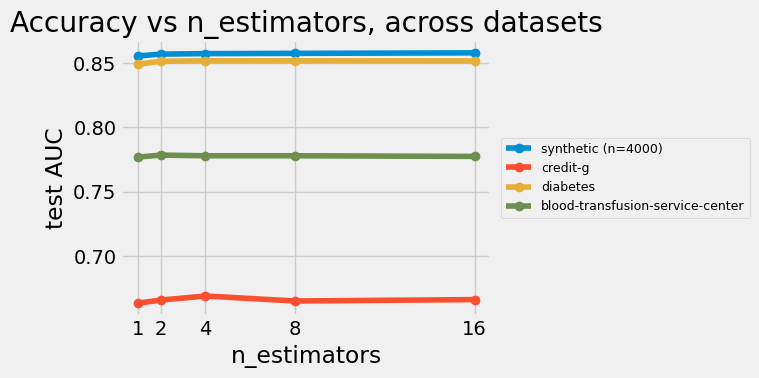

In [8]:
# Accuracy saturates with n_estimators, but is that a quirk of one synthetic task? Sweep several
# datasets of different size and difficulty. We warm up once per dataset so timing is not measured here.
datasets = {"synthetic (n=4000)": make_data(n=4000, seed=0)}
for name in ["credit-g", "diabetes", "blood-transfusion-service-center"]:
    datasets[name] = load_openml_binary(name)

estimator_counts = [1, 2, 4, 8, 16]
rows = []
for dataset_name, (X, y) in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
    TabPFNClassifier(n_estimators=1, random_state=0).fit(X_train, y_train).predict_proba(X_test)  # warm up
    record = {"dataset": dataset_name}
    for n_estimators in estimator_counts:
        model = TabPFNClassifier(n_estimators=n_estimators, random_state=0).fit(X_train, y_train)
        record[f"n={n_estimators}"] = round(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]), 4)
    rows.append(record)
auc_table = pd.DataFrame(rows).set_index("dataset")
print(auc_table.to_string())

fig, ax = plt.subplots(figsize=(7.5, 4))
for dataset_name in auc_table.index:
    ax.plot(estimator_counts, auc_table.loc[dataset_name].values, marker="o", label=dataset_name)
ax.set_xlabel("n_estimators"); ax.set_ylabel("test AUC"); ax.set_xticks(estimator_counts)
ax.set_title("Accuracy vs n_estimators, across datasets")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
fig.tight_layout(); plt.show()

In [9]:
# The cost side: time grows with the estimator count, each one is another pass over the data.
X, y = make_data(n=4000, seed=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
TabPFNClassifier(n_estimators=1, random_state=0).fit(X_train, y_train).predict_proba(X_test)  # warm up
for n_estimators in [1, 4, 16]:
    start = time.perf_counter()
    TabPFNClassifier(n_estimators=n_estimators, random_state=0).fit(X_train, y_train).predict_proba(X_test)
    print(f"n_estimators={n_estimators:2d}: {time.perf_counter() - start:.2f}s")

n_estimators= 1: 0.82s


n_estimators= 4: 1.33s


n_estimators=16: 3.45s


On the default preprocessing, the shape is the same on every dataset: accuracy is settled by 2 to 4
estimators, 4 to 16 adds a few thousandths at most, and time grows roughly linearly with the count. The
small dips in the printed table (credit-g and blood-transfusion shed a thousandth or two between n=2 and
n=8) are single-split noise, not the curve bending down: averaging more views lowers variance and cannot
raise the expected error, so on a fixed split the line wobbles within noise while the underlying curve is
flat-to-up. But is "2 to 4" a property of TabPFN, or of the *default* menu? An estimator only helps when
its view differs from the others, and `inference_config` sets that diversity. The next cell varies it.

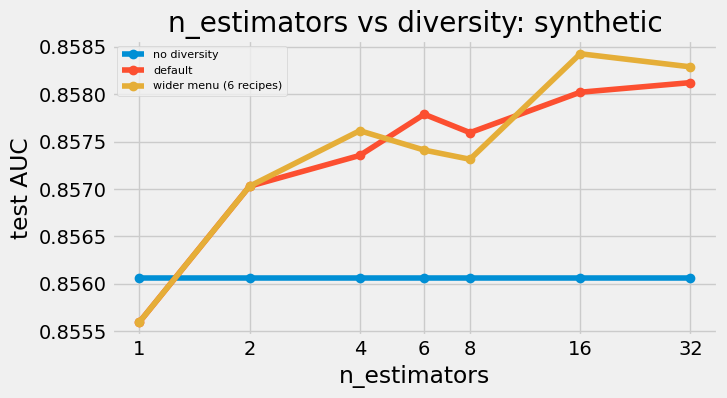

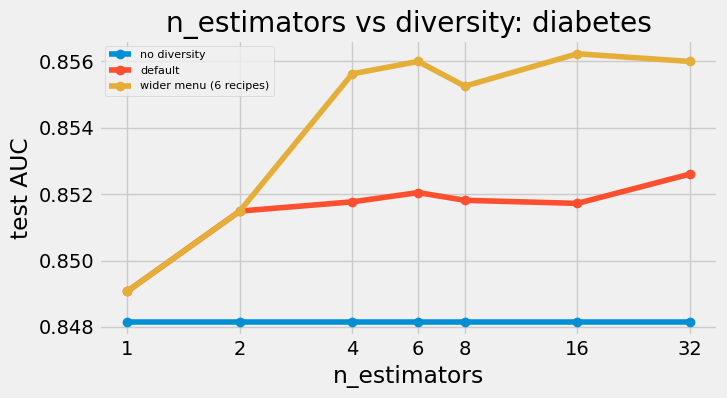

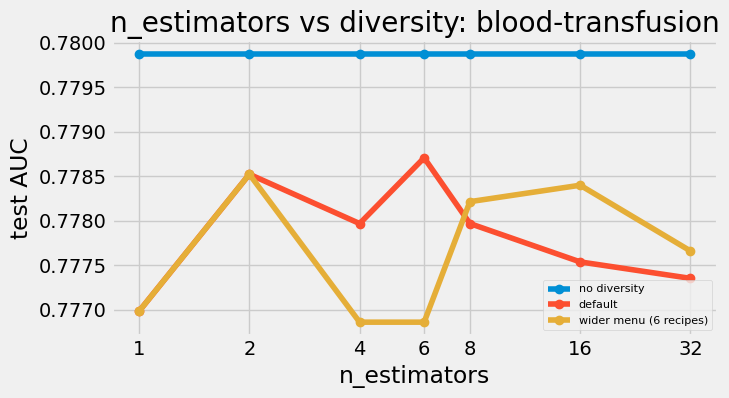

In [10]:
# Is "2 to 4 estimators" universal, or a property of the default menu? An estimator only helps if its view
# differs from the rest, and inference_config sets that. Sweep n_estimators under three configs: no
# diversity (one recipe, shifts off), the default 2-recipe menu, and a wider menu that is the default plus
# four more recipes (so default and wider share their first two and split once the extras enter).
from tabpfn.preprocessing import PreprocessorConfig
from tqdm.auto import tqdm

config_datasets = {"synthetic": make_data(n=4000, seed=0),
                   "diabetes": load_openml_binary("diabetes"),
                   "blood-transfusion": load_openml_binary("blood-transfusion-service-center")}

# read the default menu off a quick fit, then build "wider" as that menu plus four more recipes
default_menu = list(TabPFNClassifier(n_estimators=8, random_state=0)
                    .fit(*config_datasets["synthetic"]).inference_config_.PREPROCESS_TRANSFORMS)
wider_menu = default_menu + [
    PreprocessorConfig(name="safepower", categorical_name="numeric"),
    PreprocessorConfig(name="none", categorical_name="numeric"),
    PreprocessorConfig(name="quantile_norm", categorical_name="numeric", global_transformer_name="svd_quarter_components"),
    PreprocessorConfig(name="robust", categorical_name="numeric"),
]
diversity_configs = {
    "no diversity": {"PREPROCESS_TRANSFORMS": [default_menu[0]], "FEATURE_SHIFT_METHOD": None, "CLASS_SHIFT_METHOD": None},
    "default": {},
    "wider menu (6 recipes)": {"PREPROCESS_TRANSFORMS": wider_menu},
}
estimator_grid = [1, 2, 4, 6, 8, 16, 32]

config_rows = []
for data_name, (X, y) in tqdm(config_datasets.items(), desc="n_estimators x config"):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
    for config_name, cfg in diversity_configs.items():
        for n in estimator_grid:
            model = TabPFNClassifier(n_estimators=n, random_state=0, inference_config=cfg).fit(X_train, y_train)
            auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
            config_rows.append({"dataset": data_name, "config": config_name, "n_estimators": n, "auc": auc})

config_sweep = pd.DataFrame(config_rows)
for data_name in config_datasets:
    rows_for_dataset = config_sweep[config_sweep.dataset == data_name]
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    for config_name in diversity_configs:
        line = rows_for_dataset[rows_for_dataset.config == config_name].sort_values("n_estimators")
        ax.plot(line.n_estimators, line.auc, marker="o", label=config_name)
    ax.set_xscale("log", base=2); ax.set_xticks(estimator_grid); ax.set_xticklabels(estimator_grid)
    ax.set_title(f"n_estimators vs diversity: {data_name}")
    ax.set_xlabel("n_estimators"); ax.set_ylabel("test AUC")
    ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()

Three configs, same sweep. The wider menu is the default plus four more recipes, so default and wider start
identical and split once the extra recipes enter:

- **no diversity** (one recipe, feature and class shifts off): flat. Every n gives the same AUC; the extra
  estimators are wasted.
- **default** (the two-recipe menu): saturates by 2 to 4.
- **wider menu** (six recipes): keeps climbing past where the default flattens, to about 16.

So the saturation point is not a law; it tracks how diverse the views are. That diversity is two things at once, the recipe menu and the per-estimator column shuffle, so the climb you see reflects both, not the menu alone. The wider menu pays off most
where the default's own recipe fits the data poorly: on diabetes `squashing+SVD` is the weakest single
recipe and the added ones beat it, so averaging them in lifts AUC; on synthetic and blood-transfusion it is
already fine, so little is gained. Rule of thumb: 8 is a safe default *for the default menu*, a richer menu
rewards more estimators, and no diversity wastes them. (Clearest on diabetes; blood-transfusion is too
small and noisy to read.)

### What keeps the views different

The menu above lists the diversity sources; here we test the two main ones. Identical preprocessing
$\Rightarrow$ averaging buys nothing. Within one recipe the copies differ mostly by column order
(`FEATURE_SHIFT_METHOD`). Turn that off and they collapse.

In [11]:
# Turn the column reordering off and watch the redundant copies collapse. Using per_estimator_positive_proba
# from above, we compare a same-recipe pair (est0 vs est1) against a different-recipe pair (est0 vs est4),
# with FEATURE_SHIFT_METHOD on (the default "shuffle") and off (None).
# Own split: the n_estimators sweeps above leave the shared X_train pointing at their last dataset, so we
# rebuild the synthetic split here rather than inherit it.
X, y = make_data(n=4000, seed=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)

rows = []
for shift_method in ["shuffle", None]:
    model = TabPFNClassifier(n_estimators=8, random_state=0,
                             inference_config={"FEATURE_SHIFT_METHOD": shift_method}).fit(X_train, y_train)
    proba = per_estimator_positive_proba(model, X_test)
    rows.append({
        "FEATURE_SHIFT_METHOD": str(shift_method),
        "|est0-est1| same recipe": round(float(np.abs(proba[0] - proba[1]).mean()), 4),
        "|est0-est4| diff recipe": round(float(np.abs(proba[0] - proba[4]).mean()), 4),
        "ensemble AUC": round(roc_auc_score(y_test, proba.mean(0)), 4),
    })
print(pd.DataFrame(rows).to_string(index=False))

FEATURE_SHIFT_METHOD  |est0-est1| same recipe  |est0-est4| diff recipe  ensemble AUC
             shuffle                   0.0241                   0.0383        0.8576
                None                   0.0000                   0.0404        0.8575


- **shift on** (default `"shuffle"`): same-recipe estimators still differ, each sees its own random column order.
- **shift off** (`None`): that pair collapses to bit-identical predictions, difference exactly `0.0000`.
- the different-recipe pair stays apart either way (squashing and quantile feed different numbers).

Ensemble AUC barely moves: the menu has only 2 distinct recipes, and the shift only diversifies the copies of each. Killing it makes the copies redundant but keeps the recipe-level diversity that carries the ensemble.

Mechanism (`shuffle_features_step.py`): `"shuffle"` = a fresh `rng.permutation` per estimator, `feature_shift_count` ignored; `"rotate"` = roll by that count; `None` = identity. So `feature_shift_count` only bites in `"rotate"` mode.

In [12]:
# Is the class shift pulling any weight? Isolate it: pin a single recipe (so the menu adds no diversity)
# and turn the feature shift off, leaving the class permutation as the ONLY thing that can separate
# estimators. Then read it on versus off.
from tabpfn.preprocessing import PreprocessorConfig

# Own split (same reason as the feature-shift cell: do not inherit X_train from the sweeps above).
X, y = make_data(n=4000, seed=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)

single_recipe = [PreprocessorConfig(name="quantile_uni", categorical_name="numeric")]
rows = []
for class_shift in ["shuffle", None]:
    model = TabPFNClassifier(n_estimators=8, random_state=0,
                inference_config={"PREPROCESS_TRANSFORMS": single_recipe,
                                  "FEATURE_SHIFT_METHOD": None,
                                  "CLASS_SHIFT_METHOD": class_shift}).fit(X_train, y_train)
    proba = per_estimator_positive_proba(model, X_test)
    estimator_spread = float(np.abs(proba - proba.mean(0, keepdims=True)).mean())
    rows.append({
        "CLASS_SHIFT_METHOD": str(class_shift),
        "estimator spread": round(estimator_spread, 5),
        "ensemble AUC": round(roc_auc_score(y_test, proba.mean(0)), 4),
    })
print(pd.DataFrame(rows).to_string(index=False))

# And the same on/off flip on the full default configuration (everything else left on):
for class_shift in ["shuffle", None]:
    model = TabPFNClassifier(n_estimators=8, random_state=0,
                             inference_config={"CLASS_SHIFT_METHOD": class_shift}).fit(X_train, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"default config, CLASS_SHIFT_METHOD={str(class_shift):8s} -> AUC={auc:.4f}")

CLASS_SHIFT_METHOD  estimator spread  ensemble AUC
           shuffle           0.00768        0.8557
              None           0.00000        0.8550


default config, CLASS_SHIFT_METHOD=shuffle  -> AUC=0.8576


default config, CLASS_SHIFT_METHOD=None     -> AUC=0.8574


Class shift isolated (single recipe, feature-shift off):

- **on**: estimators differ a little (spread about 0.008), AUC nudges up.
- **off**: all 8 identical, spread exactly 0.
- on the full default config, the on/off flip moves AUC by about 0.0002.

v3 has no fixed class slots, so permuting labels and un-permuting the output is close to a no-op. A real diversity source, the weakest one.

**Takeaway.** Each estimator = the same frozen network on a differently-prepared view; averaging lowers variance. The one knob you normally touch is `PREPROCESS_TRANSFORMS` (swap the recipe). Leave the rest at defaults; `random_state` is the only handle on the exact draws.

### Which knobs move the output, and which way

The sweep below flips each preprocessing knob from its default and reads four metrics. The result is
mostly flat, and "preprocessing barely matters" is the wrong lesson to draw. Name what each knob can
physically touch and the flatness explains itself. Every one lands in one of four buckets:

- **(a) a monotone per-feature reshape** (the scalers, the outlier clip): a tree's splits are exactly
  invariant to it, and TabPFN turns out to be nearly so (an empirical result, shown below), unlike a
  linear model. Mostly calibration and the tails move, not the ranking.
- **(b) a derived column handed over** (SVD, polynomial): helps only when the model cannot recover that
  signal in context at your sample size.
- **(c) a modality boundary crossed** (the categorical-detection thresholds): the encoding flips and the
  prediction changes. This is the categorical chapter's subject, not repeated here.
- **(d) ensemble decorrelation only** (the feature and class shifts from above): variance down, the
  expected prediction unchanged.

Bucket (a) is the one a gradient-boosting practitioner recognizes fastest, so we show it directly before
the sweep: who actually needs feature scaling?

             LogReg  RandomForest  HistGBM  TabPFN
scaling                                           
raw          0.8059        0.8844   0.8804  0.9024
standardize  0.9032        0.8843   0.8804  0.9023
quantile     0.9023        0.8841   0.8804  0.9018

AUC swing across scalings (max - min) per model:
LogReg          0.0973
RandomForest    0.0003
HistGBM         0.0000
TabPFN          0.0006


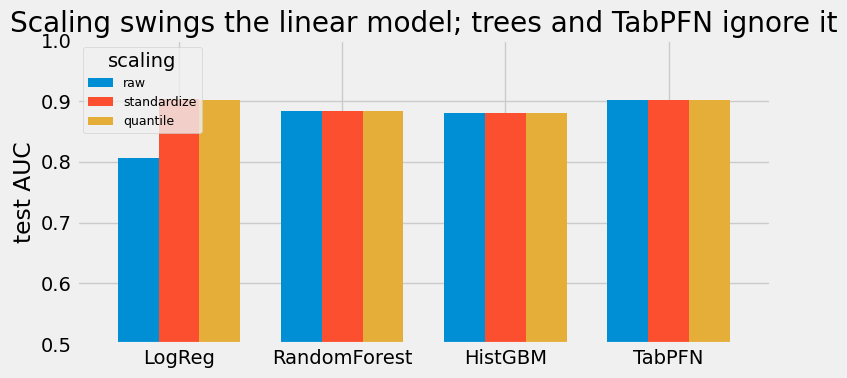

In [13]:
# Scaling is the reflex you cannot skip for a linear model and can ignore for a tree. We build features
# whose raw scales span 1e-2 to 1e3, with the signal linear in their STANDARDIZED values (same information
# at every scaling), then score four models under three scalings: raw, standardize, quantile. Read each row
# as "does this model care how the columns are scaled?".
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from tqdm.auto import tqdm

def make_mixed_scale_data(n=4000, n_features=12, n_signal=5, seed=0):
    """Features whose raw scales span 1e-2 to 1e3, signal linear in their standardized values.
    Same information at every scaling; only a scale-sensitive model (a linear one) should care."""
    rng = np.random.RandomState(seed)
    column_scale = np.logspace(-2, 3, n_features)                       # 0.01 ... 1000
    standardized = rng.randn(n, n_features)
    observed = standardized * column_scale
    logit = standardized[:, :n_signal].sum(axis=1) * 1.2
    label = (rng.rand(n) < 1 / (1 + np.exp(-logit))).astype(int)
    return pd.DataFrame(observed, columns=[f"x{i}" for i in range(n_features)]), label

scale_X, scale_y = make_mixed_scale_data()
scale_X_train, scale_X_test, scale_y_train, scale_y_test = train_test_split(
    scale_X, scale_y, test_size=0.4, random_state=0, stratify=scale_y)

scalings = {"raw": None, "standardize": StandardScaler(),
            "quantile": QuantileTransformer(output_distribution="normal", random_state=0)}
models = {"LogReg": lambda: LogisticRegression(max_iter=2000),
          "RandomForest": lambda: RandomForestClassifier(n_estimators=300, random_state=0),
          "HistGBM": lambda: HistGradientBoostingClassifier(random_state=0),
          "TabPFN": lambda: TabPFNClassifier(random_state=0)}

scale_rows = []
for scaling_name, scaler in tqdm(scalings.items(), desc="scaling"):
    train_scaled = scale_X_train if scaler is None else pd.DataFrame(scaler.fit_transform(scale_X_train))
    test_scaled = scale_X_test if scaler is None else pd.DataFrame(scaler.transform(scale_X_test))
    scale_record = {"scaling": scaling_name}
    for model_name, make_model in models.items():
        proba = make_model().fit(train_scaled, scale_y_train).predict_proba(test_scaled)[:, 1]
        scale_record[model_name] = roc_auc_score(scale_y_test, proba)
    scale_rows.append(scale_record)
auc_by_scaling = pd.DataFrame(scale_rows).set_index("scaling")
print(auc_by_scaling.round(4).to_string())
print("\nAUC swing across scalings (max - min) per model:")
print((auc_by_scaling.max() - auc_by_scaling.min()).round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
auc_by_scaling.T.plot.bar(ax=ax, width=0.75)
ax.set_ylabel("test AUC"); ax.set_ylim(0.5, 1.0); ax.set_xlabel("")
ax.set_title("Scaling swings the linear model; trees and TabPFN ignore it")
ax.legend(title="scaling", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
fig.tight_layout(); plt.show()

Same data, three scalings, four models. LogReg swings by about **0.10 AUC** between raw and scaled, while
RandomForest, HistGBM, and TabPFN barely move (under 0.001 here). The magnitude is dataset-specific, but
the split is the point: TabPFN tracks the tree models, not the linear one. A tree is exactly invariant to a
monotone change of units (it only reshuffles split thresholds); TabPFN is not guaranteed to be, it reads
the values in context, but empirically it barely moves, an order of magnitude under LogReg, so the scaler
menu inside `inference_config` is, for ranking, close to a non-event.

What the scaler still moves is calibration. In the sweep that follows, `numeric transform off` is the
worst knob for `dECE` (about +0.008): dropping the scaler leaves the probabilities less calibrated even
though the ranking holds. That is bucket (a) in full, a monotone reshape is ranking-invariant and
calibration-sensitive.

In [14]:
# Flip each preprocessing knob once from its default and read four familiar metrics, averaged across
# datasets: AUC and AUPRC (ranking), F1 (the 0.5-cutoff decision), and ECE (calibration). Each is shown as
# the change from the default, so 0 means the knob did nothing.
from dataclasses import replace
from tabpfn.preprocessing import PreprocessorConfig
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

def all_metrics(y_true, proba):
    return {"AUC": roc_auc_score(y_true, proba), "AUPRC": average_precision_score(y_true, proba),
            "F1": f1_score(y_true, (proba >= 0.5).astype(int)),
            "ECE": expected_calibration_error(y_true, proba)}

sweep_datasets = {"synthetic": make_data(n=4000, seed=0)}
for name in ["credit-g", "diabetes", "blood-transfusion-service-center"]:
    sweep_datasets[name] = load_openml_binary(name)

def knob_variants(default_menu):
    """One inference_config change per knob, each starting from the default."""
    return {
        "numeric transform off": {"PREPROCESS_TRANSFORMS": [replace(c, name="none") for c in default_menu]},
        "outlier clip off":      {"OUTLIER_REMOVAL_STD": None},
        "SVD off":               {"PREPROCESS_TRANSFORMS": [replace(c, global_transformer_name=None) for c in default_menu]},
        "fingerprint off":       {"FINGERPRINT_FEATURE": False},
        "feature reorder off":   {"FEATURE_SHIFT_METHOD": None},
        "class permutation off": {"CLASS_SHIFT_METHOD": None},
        "polynomial on":         {"POLYNOMIAL_FEATURES": "all"},
        "row subsample to 0.5":  {"SUBSAMPLE_SAMPLES": 0.5},
    }

records = []
for data_name, (X, y) in tqdm(sweep_datasets.items(), desc="knob sweep"):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
    default_model = TabPFNClassifier(n_estimators=8, random_state=0).fit(X_train, y_train)
    base = all_metrics(y_test, default_model.predict_proba(X_test)[:, 1])
    default_menu = default_model.inference_config_.PREPROCESS_TRANSFORMS
    for knob, change in knob_variants(default_menu).items():
        model = TabPFNClassifier(n_estimators=8, random_state=0, inference_config=change).fit(X_train, y_train)
        scores = all_metrics(y_test, model.predict_proba(X_test)[:, 1])
        records.append({"knob": knob, **{f"d{k}": scores[k] - base[k] for k in base}})

sweep = pd.DataFrame(records).groupby("knob")[["dAUC", "dAUPRC", "dF1", "dECE"]].mean().round(4)
print("Change in each metric when a knob is flipped from default, averaged over 4 datasets.")
print("ranking: dAUC, dAUPRC (higher better) | decision: dF1 (higher better) | calibration: dECE (higher worse)\n")
print(sweep.to_string())

Change in each metric when a knob is flipped from default, averaged over 4 datasets.
ranking: dAUC, dAUPRC (higher better) | decision: dF1 (higher better) | calibration: dECE (higher worse)

                         dAUC  dAUPRC     dF1    dECE
knob                                                 
SVD off                0.0011 -0.0000 -0.0021  0.0037
class permutation off -0.0002 -0.0002 -0.0010  0.0038
feature reorder off    0.0014  0.0016 -0.0017  0.0053
fingerprint off        0.0003  0.0005  0.0031  0.0042
numeric transform off  0.0006  0.0010  0.0024  0.0082
outlier clip off       0.0000  0.0000  0.0000  0.0000
polynomial on         -0.0010 -0.0005  0.0067 -0.0009
row subsample to 0.5  -0.0001  0.0057 -0.0324 -0.0040


Now the rest of the menu, every knob flipped from its default, averaged over four datasets. Read the rows
through the four buckets:

- **Ranking is flat for every knob** (`dAUC` within 0.0015, `dAUPRC` within 0.006). Buckets (a) and (d)
  predict exactly this: monotone reshapes and ensemble decorrelation do not change which rows rank
  highest.
- **Bucket (a), calibration moves where ranking does not.** `numeric transform off` is the worst for
  calibration (`dECE` +0.008). `outlier clip off` is exactly inert (all zeros), because the squashing and
  quantile transforms already bound the data inside 12σ, leaving nothing to clip.
- **Bucket (b), the derived columns.** `SVD off` barely moves anything here (`dAUC` +0.001): the default
  data has no dense rotated signal for SVD to hand over. Put into the regime SVD is built for (the signal
  living in one linear combination of many features, at small n), it adds only a small, consistent lift
  and no more, because TabPFN recovers most of that axis in context. `polynomial on` is the same story
  for products, measured directly in the feature-engineering chapter, so it stays a pointer here.
- **The exception is the context-size knob.** `row subsample to 0.5` leaves ranking flat but drops **F1
  by 0.03**. It is not a preprocessing reshape, it shrinks the in-context training set, a learning-curve
  effect rather than a representation choice.

Two honesty notes. Averages hide per-dataset sign-flips: `polynomial on` and `row subsample` flip the
sign of their AUC effect across datasets, so a near-zero average is cancellation, not absence.
`fingerprint off` reads as inert here, and the per-row hash only earns its keep when exact-duplicate rows
would otherwise be indistinguishable, which this data does not stress. Two knobs are absent because
numeric data does not exercise them: categorical encoding (bucket (c), owned by the categorical chapter)
and feature subsampling (needs over 200 columns).

### Context size: row subsampling

`SUBSAMPLE_SAMPLES` is the one knob in this section that is not a representation choice. It hands each
estimator only a fraction of the training rows, and because TabPFN learns in context, that fraction is the
training set the model actually sees. So the sweep is a learning curve, the most familiar plot in
supervised learning: accuracy against how much data the model is given.

          context_rows     AUC  F1@0.5     ECE
fraction                                      
0.05               120  0.7425  0.6498  0.0528
0.10               240  0.7854  0.6886  0.0516
0.20               480  0.8402  0.7400  0.0481
0.35               840  0.8545  0.7630  0.0300
0.50              1200  0.8576  0.7610  0.0279
0.75              1800  0.8555  0.7585  0.0358
1.00              2400  0.8576  0.7618  0.0293


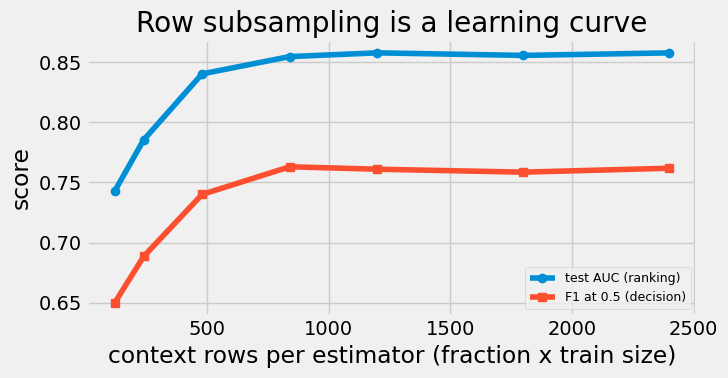

In [15]:
# SUBSAMPLE_SAMPLES gives each estimator only a fraction of the training rows. Because TabPFN learns in
# context, that fraction IS the training set the forward pass conditions on, so the sweep is the familiar
# learning-curve question: how does the model improve as it is handed more rows?
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

sub_X, sub_y = make_data(n=4000, seed=0)
sub_X_train, sub_X_test, sub_y_train, sub_y_test = train_test_split(
    sub_X, sub_y, test_size=0.4, random_state=0, stratify=sub_y)

fractions = [0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]
sub_rows = []
for fraction in tqdm(fractions, desc="subsample"):
    config = {} if fraction == 1.0 else {"SUBSAMPLE_SAMPLES": fraction}
    proba = (TabPFNClassifier(random_state=0, inference_config=config)
             .fit(sub_X_train, sub_y_train).predict_proba(sub_X_test)[:, 1])
    sub_rows.append({"fraction": fraction, "context_rows": round(fraction * len(sub_y_train)),
                     "AUC": roc_auc_score(sub_y_test, proba),
                     "F1@0.5": f1_score(sub_y_test, (proba >= 0.5).astype(int)),
                     "ECE": expected_calibration_error(sub_y_test, proba)})
subsample_curve = pd.DataFrame(sub_rows).set_index("fraction")
print(subsample_curve.round(4).to_string())

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(subsample_curve.context_rows, subsample_curve.AUC, marker="o", label="test AUC (ranking)")
ax.plot(subsample_curve.context_rows, subsample_curve["F1@0.5"], marker="s", label="F1 at 0.5 (decision)")
ax.set_xlabel("context rows per estimator (fraction x train size)")
ax.set_ylabel("score"); ax.set_title("Row subsampling is a learning curve")
ax.legend(fontsize=9); fig.tight_layout(); plt.show()

The shape is the learning curve you would expect. From 120 context rows up to about 500, AUC climbs hard
(0.74 to 0.84), and the decision and calibration climb with it. Past roughly 800 rows the curve flattens:
on this task 1,200 rows are as good as the full 2,400, so subsampling to half loses nothing here. The
interpretation is the point, not the breakpoint (which is dataset-specific): subsampling does not reshape a
feature, it shrinks the training set, so it moves ranking, decision, and calibration together, the way
handing any model less data would. Reach for it to trade accuracy for speed on large training sets, and
read the curve to see how far down you can go before the model starts to starve. It is the opposite end of
the trade from `n_estimators`: more estimators average more views of the same rows, `SUBSAMPLE_SAMPLES`
changes how many rows each view gets.

## Calibration knobs

These two knobs matter the moment you stop ranking and start *deciding*. Most production uses of a
classifier threshold its probability to take an action: call this customer, review this claim, hold
this transaction. A cutoff like 0.5 only means "more likely than not" when the probabilities are
*calibrated*. `balance_probabilities` and `softmax_temperature` reshape the probability distribution
without touching the ranking, both are monotone transforms, so AUC and AUPRC are unchanged by
construction, which means what they really move is where your threshold bites. We show this first on
the shape of the output, then on a real imbalanced decision.

calibration error (ECE):  default 0.021   balanced 0.311


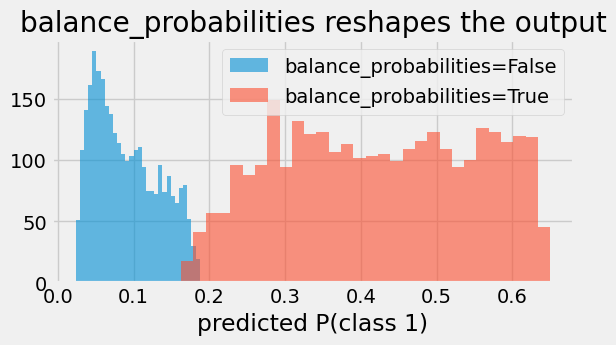

In [16]:
# balance_probabilities on a HARD, imbalanced task (uncertain model, so the shift is visible).
rng = np.random.RandomState(1)
m = 6000
Xb = rng.randn(m, 4)
logit = 0.5 * Xb[:, 0] - 2.2                                 # weak signal + low base rate (uncertain, ~11% positive)
yb = (rng.rand(m) < 1 / (1 + np.exp(-logit))).astype(int)
Xtr, Xte = pd.DataFrame(Xb[:m // 2]), pd.DataFrame(Xb[m // 2:]); ytr, yte = yb[:m // 2], yb[m // 2:]

p_off = TabPFNClassifier(random_state=0).fit(Xtr, ytr).predict_proba(Xte)[:, 1]
p_on  = TabPFNClassifier(balance_probabilities=True, random_state=0).fit(Xtr, ytr).predict_proba(Xte)[:, 1]

print(f"calibration error (ECE):  default {expected_calibration_error(yte, p_off):.3f}"
      f"   balanced {expected_calibration_error(yte, p_on):.3f}")

plt.figure(figsize=(6, 3))
plt.hist(p_off, bins=30, alpha=0.6, label="balance_probabilities=False")
plt.hist(p_on,  bins=30, alpha=0.6, label="balance_probabilities=True")
plt.legend(); plt.xlabel("predicted P(class 1)"); plt.title("balance_probabilities reshapes the output")
plt.show()

The histogram shows the distribution lifting toward the minority class, but `balance_probabilities` is not
learning a new shape. It applies a fixed rule: divide each class probability by that class's training
frequency, then renormalize. For two classes that is a prior correction with a closed form, and the cell
checks it against TabPFN's actual balanced output.

In [17]:
# balance_probabilities is not a black box: it divides each class probability by that class's training
# frequency and renormalizes (a pure prior correction). We rebuild the balanced output from the default
# output p_off and the training base rate, then read what the correction does to a 0.5 threshold.
pi = ytr.mean()                                                  # training positive rate (the prior)
reconstructed = (p_off / pi) / (p_off / pi + (1 - p_off) / (1 - pi))
print(f"training base rate pi               = {pi:.3f}")
print(f"max |balanced - prior-correction|   = {np.abs(p_on - reconstructed).max():.6f}")

# In log-odds that correction is one subtraction: logit(p') = logit(p) - logit(pi). So thresholding the
# balanced output at 0.5 flags exactly the rows the default output puts above the base rate pi.
same_rows = ((p_on >= 0.5) == (p_off >= pi)).mean()
print(f"rows where (balanced >= 0.5) == (default >= pi): {same_rows:.3f}")

training base rate pi               = 0.110
max |balanced - prior-correction|   = 0.000000
rows where (balanced >= 0.5) == (default >= pi): 1.000


So the knob has a closed form. It divides each class probability by its training frequency and
renormalizes, which for two classes is `p' = (p/π) / (p/π + (1-p)/(1-π))`. The reconstruction matches
TabPFN's balanced output to the sixth decimal, so this is the exact rule, not an approximation. In log-odds
it is one subtraction, `logit(p') = logit(p) - logit(π)`, the knob removes the prior. That single fact
explains the section. A constant shift in log-odds cannot reorder anything, so AUC and AUPRC stay put. And
thresholding the balanced output at 0.5 is identical to thresholding the default output at the base rate π:
above, every row clears both or neither. So `balance_probabilities=True` read at a 0.5 cutoff is a compact
way to say "flag everything above the base rate". Reach for it when your action fires at a fixed 0.5 and you
want that to mean the base rate, never to improve a ranking.

temperature 0.5: calibration error (ECE) 0.110


temperature 0.9: calibration error (ECE) 0.029


temperature 2.0: calibration error (ECE) 0.056


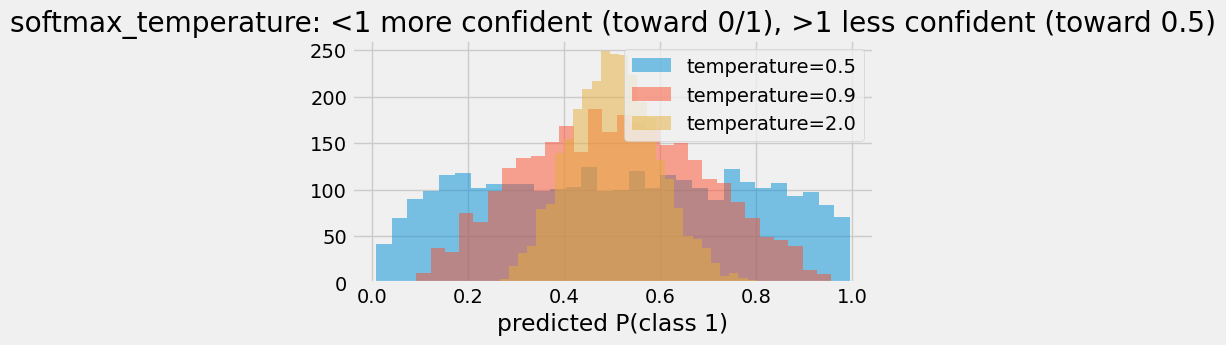

In [18]:
# softmax_temperature on a HARD, balanced task (uncertain model, so sharpen/soften shows).
rng = np.random.RandomState(2)
m = 6000
Xt = rng.randn(m, 6)
logit = 0.6 * Xt[:, 0] + 0.4 * Xt[:, 1]
yt = (rng.rand(m) < 1 / (1 + np.exp(-logit))).astype(int)
Xtr, Xte = pd.DataFrame(Xt[:m // 2]), pd.DataFrame(Xt[m // 2:]); ytr, yte = yt[:m // 2], yt[m // 2:]

plt.figure(figsize=(6, 3))
for t in [0.5, 0.9, 2.0]:
    p = TabPFNClassifier(softmax_temperature=t, random_state=0).fit(Xtr, ytr).predict_proba(Xte)[:, 1]
    print(f"temperature {t}: calibration error (ECE) {expected_calibration_error(yte, p):.3f}")
    plt.hist(p, bins=30, alpha=0.5, label=f"temperature={t}")
plt.legend(); plt.xlabel("predicted P(class 1)"); plt.title("softmax_temperature: <1 more confident (toward 0/1), >1 less confident (toward 0.5)")
plt.show()

### Tuning the dial: the temperature U-curve

The three histograms show what temperature does to the shape of the output. To see what it does to a
metric, sweep it finely. `softmax_temperature` divides each estimator's logits before its softmax, so a
single fit gives the whole family exactly: we read the per-estimator logits once, re-temper them, and
average them the way TabPFN does. The question is where calibration is best, and whether that point moves
between an easy task and a hard one.

uncertain (weak signal)    AUC 0.6758 to 0.6759 across T   ECE 0.029 at default 0.9 -> 0.018 at best T=1.2


confident (strong signal)  AUC 0.9099 to 0.9099 across T   ECE 0.036 at default 0.9 -> 0.025 at best T=1.0


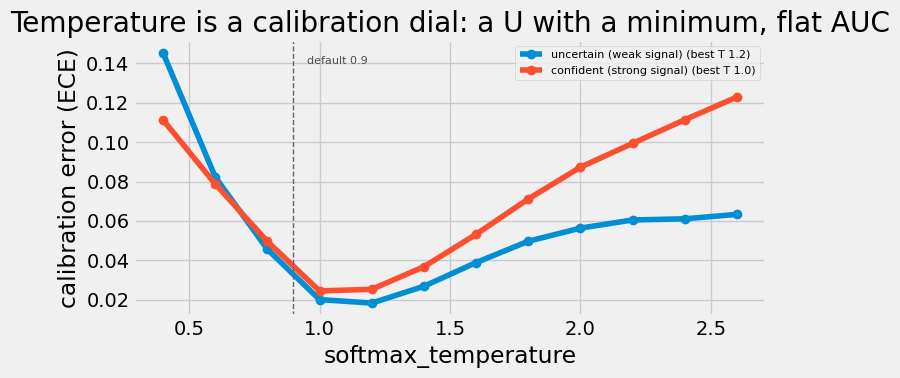

In [19]:
# softmax_temperature divides EACH estimator's logits before its softmax, then the estimators are averaged.
# So one fit gives the whole family exactly: read the per-estimator logits once and re-temper them. We sweep
# T and read calibration (ECE) and ranking (AUC) on two tasks, one the model is unsure about, one it is
# confident on.
import torch

def ensemble_proba_at_temperature(raw_logits, temperature):
    """P(class 1) the way TabPFN forms it: soften each estimator's logits by T, softmax, then average."""
    return torch.softmax(raw_logits / temperature, dim=-1)[:, :, 1].mean(0).cpu().numpy()

def make_signal_task(weights, seed):
    rng = np.random.RandomState(seed)
    X = rng.randn(6000, 6)
    prob = 1 / (1 + np.exp(-(weights[0] * X[:, 0] + weights[1] * X[:, 1])))
    y = (rng.rand(6000) < prob).astype(int)
    return pd.DataFrame(X[:3000]), pd.DataFrame(X[3000:]), y[:3000], y[3000:]

temperature_grid = np.round(np.linspace(0.4, 2.6, 12), 2)
temp_tasks = {"uncertain (weak signal)": make_signal_task((0.6, 0.4), seed=2),
              "confident (strong signal)": make_signal_task((2.6, 1.6), seed=5)}

fig, ax = plt.subplots(figsize=(7.5, 4))
for task_name, (X_train, X_test, y_train, y_test) in temp_tasks.items():
    fitted = TabPFNClassifier(random_state=0).fit(X_train, y_train)
    raw_logits = torch.from_numpy(fitted.predict_raw_logits(X_test))  # (n_estimators, n, n_classes), public API
    aucs = [roc_auc_score(y_test, ensemble_proba_at_temperature(raw_logits, T)) for T in temperature_grid]
    ece_curve = [expected_calibration_error(y_test, ensemble_proba_at_temperature(raw_logits, T)) for T in temperature_grid]
    best_T = temperature_grid[int(np.argmin(ece_curve))]
    ece_default = expected_calibration_error(y_test, fitted.predict_proba(X_test)[:, 1])
    print(f"{task_name:26s} AUC {min(aucs):.4f} to {max(aucs):.4f} across T   "
          f"ECE {ece_default:.3f} at default 0.9 -> {min(ece_curve):.3f} at best T={best_T:.1f}")
    ax.plot(temperature_grid, ece_curve, marker="o", label=f"{task_name} (best T {best_T:.1f})")
ax.axvline(0.9, color="0.4", ls="--", lw=1)
ax.text(0.95, ax.get_ylim()[1] * 0.92, "default 0.9", fontsize=8, color="0.3")
ax.set_xlabel("softmax_temperature"); ax.set_ylabel("calibration error (ECE)")
ax.set_title("Temperature is a calibration dial: a U with a minimum, flat AUC")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

Two readings, both useful. First, ranking barely moves: the AUC printed for each task is flat across
temperature, its range spanning about 0.0001. Each estimator's softmax is monotone in its own logits, and
averaging eight of them leaves the row order intact here, so temperature is effectively a pure confidence
dial. Second, calibration traces a clean U with a single minimum, the picture behind "temperature scaling"
in the calibration literature. On both the uncertain and the confident task that minimum sits near
T = 1.0 to 1.2, just above the default 0.9: the pretrained ensemble is a touch over-confident here, so
softening it slightly is the most calibration you can buy, and the gain over the default is small (ECE
about 0.02 against 0.03). The optimum landing near the same place on two different tasks is why 0.9 is a
safe default and why you rarely move it. Reach for temperature only when you need calibrated probabilities
and can measure ECE on held-out data, then turn it toward the U minimum, not to move a ranking it leaves
alone.

In [20]:
# A real threshold decision: a marketing campaign on imbalanced data (~12% subscribe). We threshold
# the probability at 0.5 to decide whom to call, and watch what the knob does to that decision.
# load_openml_binary keeps only bank-marketing's numeric columns and factorizes the label; the printed
# rate confirms class 1 is the ~12% minority (clients who subscribed), which is the positive class here.
X, y = load_openml_binary("bank-marketing", n_cap=6000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
print(f"positive (subscribe) rate: {y.mean():.3f}\n")

for label, settings in [("default", {}), ("balance_probabilities=True", {"balance_probabilities": True})]:
    p = TabPFNClassifier(random_state=0, **settings).fit(X_train, y_train).predict_proba(X_test)[:, 1]
    flagged = p >= 0.5
    print(f"{label}:")
    print(f"  AUC {roc_auc_score(y_test, p):.3f} (ranking)   "
          f"ECE {expected_calibration_error(y_test, p):.3f} (calibration)   mean prob {p.mean():.3f}")
    print(f"  at threshold 0.5 -> call {flagged.mean():.1%} of customers, "
          f"precision {precision_score(y_test, flagged, zero_division=0):.2f}, "
          f"recall {recall_score(y_test, flagged):.2f}\n")

positive (subscribe) rate: 0.117



default:
  AUC 0.883 (ranking)   ECE 0.010 (calibration)   mean prob 0.110
  at threshold 0.5 -> call 5.4% of customers, precision 0.62, recall 0.29



balance_probabilities=True:
  AUC 0.883 (ranking)   ECE 0.196 (calibration)   mean prob 0.313
  at threshold 0.5 -> call 28.1% of customers, precision 0.35, recall 0.83



The histograms and the campaign tell one story. The AUC is identical with and without the knob, the
ranking does not move, so neither knob can "improve" a ranking metric. What moves is the *operating
point*. The default model is well-calibrated (ECE around 0.01, mean probability near the 12% base
rate), so a 0.5 cutoff calls about 5% of customers at decent precision. `balance_probabilities` lifts
the whole distribution toward the minority class (mean probability jumps, ECE blows up past 0.1), so
the same 0.5 cutoff now calls roughly five times as many people: recall soars, precision falls. That is
the knob's actual job, shifting where a fixed threshold lands.

`softmax_temperature` is the same lesson in the other direction: below 1 it sharpens probabilities
toward 0 and 1, above 1 it softens them toward 0.5, and the default 0.9 sits near the best-calibrated
point (the printed ECE is lowest there, about 0.03 against 0.11 at 0.5 and 0.06 at 2.0). Reach for
either knob only when a fixed cutoff or a calibrated probability is what you actually need, never to
improve AUC. (A gradient-boosting model's `scale_pos_weight` is what people often expect to help
ranking; this is not that.)

## Speed and memory

TabPFN has no training loop, so its `.fit()` does something unusual: it stores your training data as
the *context* the forward pass will condition on. `fit_mode` decides how much of that conditioning is
precomputed and cached, which is the clearest window into how in-context learning actually runs. The
preprocessing it refers to is the same ensemble we keep meeting: TabPFN builds one differently
preprocessed copy of the data per estimator.

- `low_memory` caches nothing. Every `.predict()` re-runs the full preprocessing, fitting the
  preprocessors on the training data and transforming both train and test, once per estimator, and
  then the forward pass. Smallest memory footprint, slowest repeated prediction.
- `fit_preprocessors` (the default) fits the preprocessors once at `.fit()` and caches the transformed
  *training* data (in CPU RAM). Each `.predict()` then only transforms the test rows and runs the
  forward pass, no re-fitting of the preprocessing.
- `fit_with_cache` does all of that and, in addition, pushes the preprocessed training context through
  the transformer at `.fit()` to compute and store its **key-value cache**, one per estimator. In a
  transformer the training rows become the keys and values that test rows attend to; caching them means
  a later `.predict()` skips recomputing the whole training context and only passes the test queries
  through attention. Fastest repeated prediction, at the highest memory cost. By default (`keep_cache_on_device=True`) each
  estimator's cache stays on the inference device (the GPU when there is one); set
  `keep_cache_on_device=False` to offload it to CPU RAM, trading a little speed for device memory when a
  large cached context will not otherwise fit.

So the answer to "what gets recomputed" climbs in three steps: `low_memory` redoes the preprocessing
every time, `fit_preprocessors` keeps the preprocessed training data, and `fit_with_cache` also keeps
the attention representation of that data. None of the three changes a single prediction. The next cell
times all three on the same data.

In [21]:
X, y = make_data(n=6000, seed=1)
half = len(y) // 2
X_train, X_test, y_train, y_test = X.iloc[:half], X.iloc[half:], y[:half], y[half:]

rows = []
for fit_mode in ["low_memory", "fit_preprocessors", "fit_with_cache"]:
    start = time.perf_counter()
    model = TabPFNClassifier(fit_mode=fit_mode, random_state=0).fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    start = time.perf_counter()
    for _ in range(3):                       # repeated predictions on the same training data
        model.predict_proba(X_test)
    predict_seconds = (time.perf_counter() - start) / 3
    rows.append({"fit_mode": fit_mode, "fit_seconds": round(fit_seconds, 2),
                 "predict_seconds (avg of 3)": round(predict_seconds, 2)})
print(pd.DataFrame(rows).to_string(index=False))

         fit_mode  fit_seconds  predict_seconds (avg of 3)
       low_memory         0.62                        2.13
fit_preprocessors         0.61                        2.11
   fit_with_cache         1.86                        0.98


The shape is the point. `fit_with_cache` pays more at `.fit()`, where it builds the key-value cache,
and then predicts roughly twice as fast, because the expensive context conditioning is already done.
`low_memory` and `fit_preprocessors` fit cheaply and pay it back at predict time. So if you score the
same training data many times, `fit_with_cache` wins; if memory is tight or you predict only once,
stay with the default. Again, none of this moves a prediction, only the clock and the memory bill.

Two more performance knobs in the same spirit, neither of which touches the output:

- `memory_saving_mode` (`"auto"` by default, or `True`/`False`) batches some internal computations to
  avoid out-of-memory errors, and can even speed things up by easing memory pressure. Leave it on
  `"auto"`, force a value only when hand-tuning a tight GPU: `TabPFNClassifier(memory_saving_mode=True)`.
- `inference_precision` (`"auto"`, `"autocast"`, or a `torch.dtype`) uses mixed precision for speed by
  default; pinning a dtype trades speed for reproducibility:
  `TabPFNClassifier(inference_precision=torch.float32)` for the most repeatable run.

## Inferred settings

You do not tune the preprocessing, but you can read it. After a fit, `inference_config_` holds the
resolved limits and thresholds, and `inferred_feature_schema_` shows the modality TabPFN assigned to
each column (which is what `categorical_features_indices` would override).

In [22]:
Xq = pd.DataFrame(np.random.RandomState(0).randn(200, 5), columns=["a", "b", "c", "d", "e"])
yq = (Xq["a"] > 0).astype(int)
model = TabPFNClassifier(random_state=0).fit(Xq, yq)

print("Envelope (hard ceilings):")
for field in ["MAX_NUMBER_OF_SAMPLES", "MAX_NUMBER_OF_FEATURES", "MAX_NUMBER_OF_CLASSES"]:
    print(f"  {field} = {getattr(model.inference_config_, field)}")

print("\nPreprocessing thresholds:")
for field in ["MAX_UNIQUE_FOR_CATEGORICAL_FEATURES", "MIN_UNIQUE_FOR_NUMERICAL_FEATURES",
              "MIN_NUMBER_SAMPLES_FOR_CATEGORICAL_INFERENCE", "OUTLIER_REMOVAL_STD"]:
    print(f"  {field} = {getattr(model.inference_config_, field)}")

print("\nInferred column modality (first five columns):")
for feature in model.inferred_feature_schema_.features[:5]:
    print(f"  {feature.name}: {feature.modality.value}")

Envelope (hard ceilings):
  MAX_NUMBER_OF_SAMPLES = 1000000
  MAX_NUMBER_OF_FEATURES = 2000
  MAX_NUMBER_OF_CLASSES = 160

Preprocessing thresholds:
  MAX_UNIQUE_FOR_CATEGORICAL_FEATURES = 30
  MIN_UNIQUE_FOR_NUMERICAL_FEATURES = 4
  MIN_NUMBER_SAMPLES_FOR_CATEGORICAL_INFERENCE = 100
  OUTLIER_REMOVAL_STD = auto

Inferred column modality (first five columns):
  a: numerical
  b: numerical
  c: numerical
  d: numerical
  e: numerical


The **envelope** is the hard ceiling the checkpoint was built for (a million rows, two thousand
features, a hundred and sixty classes). Separately, `ignore_pretraining_limits` guards a softer
*recommended* operating range, and pushing well past it is where accuracy starts to slip. The
**thresholds** are the rules behind the auto-detection: a string column with 30 or fewer distinct
values is treated as categorical, a numeric column needs at least 4 distinct values to stay numeric,
and category inference needs at least 100 rows. Those are the knobs the scaling and categorical
chapters open up through `inference_config`.

Those limits and the menu above come from one checkpoint, which `model_path` selects. `"auto"` (the
default) downloads the v3 default classifier on first use and caches it; redirect the cache with the
`TABPFN_MODEL_CACHE_DIR` environment variable.

The package ships more than one checkpoint, and several map onto problems we meet elsewhere in the series:
a v2.5 family with large-features and large-samples variants for wide or tall data, and v3 variants tuned
for different numeric priors (a low-skew and a quantiles checkpoint that connect to the skewed-variables
chapter), small samples, and so on. You point at one with a filesystem path to a `.ckpt`, for example
`TabPFNClassifier(model_path="path/to/checkpoint.ckpt")`; the repository README lists the exact
identifiers. For almost every use the `"auto"` v3 default is the right answer.

## Other knobs

For completeness, the settings that did not need their own section, each as a one-line example:

- `TabPFNClassifier(average_before_softmax=True)`: average the estimators' logits before the softmax
  instead of their probabilities (only matters with `n_estimators > 1`, can help calibration and
  many-class problems).
- `TabPFNClassifier(n_preprocessing_jobs=1)`: CPU worker processes for preprocessing; `1` (the
  default) is usually best, raise it only with many cores and `n_estimators > 1`.
- `TabPFNClassifier(device="cuda")`: where inference runs; `"auto"` picks the GPU if one is present.
- `TabPFNClassifier(random_state=0)`: the seed; TabPFN fixes it to 0 by default, unlike most
  scikit-learn estimators.
- `TabPFNClassifier(show_progress_bar=True)`: a progress bar during inference.
- `TabPFNClassifier(eval_metric="roc_auc", tuning_config=...)`: opt into a post-hoc search that
  calibrates probabilities and tunes the decision threshold for the chosen metric.
- `TabPFNClassifier(differentiable_input=True)`: make the preprocessing end-to-end differentiable,
  for explainability and prompt-tuning work.

## Takeaways

- TabPFN is pretrained, so there is no hyperparameter *search*. You configure inference, and the
  defaults are strong.
- **`n_estimators`** is bagging: more views lower the variance of the average, a variance reduction
  with no training-loop overfitting (fixed-split metrics can wobble within noise), and the gain
  saturates once the views stop differing. The default is a sensible middle.
- **`balance_probabilities`** and **`softmax_temperature`** never change the ranking (a monotone
  transform cannot); they shift the operating point and the calibration. Use them only if you
  threshold at a fixed cutoff or need calibrated probabilities.
- **`categorical_features_indices`** and **`ignore_pretraining_limits`** tell TabPFN the truth about
  your data: which columns are categorical, and whether you are past its recommended size.
- **`inference_config`** is the door to the internal preprocessing (scaling, outlier clipping,
  categorical thresholds), and the envelope and thresholds above are read straight off it.
- **Preprocessing rarely moves the ranking.** TabPFN is scale-invariant the way a tree is, so the
  scaler menu, the outlier clip, and the column shuffles change calibration and ensemble diversity, not
  which rows rank highest. The choices that do move the output cross a modality boundary (categoricals)
  or change how much data conditions the model (`SUBSAMPLE_SAMPLES`).

The shift from gradient boosting: you are not tuning a model, you are configuring a fixed one, and
most of the time the defaults are the right answer.